# Visualización de datos

### Ejercicio 1
En éste ejercicio utilizamos los datos del fucking gapmider de mierda (recordar el ejercicio 10 de la práctica 2 (yo me acuerdo muy bien))

In [2]:
import pandas as pd
import seaborn.objects as so


In [3]:
url = "https://raw.githubusercontent.com/resbaz/r-novice-gapminder-files/master/data/gapminder-FiveYearData.csv"
gapminder = pd.read_csv(url)

(a) Utilizando _seaborn.objects_ , graficar la curva de la expectativa de vida en Argentina en función del año, completando el siguiente código. Sugerencia : Recordar de la práctica anterior cómo filtrar datos de un dataset.

In [5]:
datosArgentina =gapminder[gapminder['country'] == 'Argentina']
datosArgentina

,country,year,pop,continent,lifeExp,gdpPercap
48,Argentina,1952,17876956.0,Americas,62.485,5911.315053
49,Argentina,1957,19610538.0,Americas,64.399,6856.856212
50,Argentina,1962,21283783.0,Americas,65.142,7133.166023
51,Argentina,1967,22934225.0,Americas,65.634,8052.953021
52,Argentina,1972,24779799.0,Americas,67.065,9443.038526
53,Argentina,1977,26983828.0,Americas,68.481,10079.026740
54,Argentina,1982,29341374.0,Americas,69.942,8997.897412
55,Argentina,1987,31620918.0,Americas,70.774,9139.671389
56,Argentina,1992,33958947.0,Americas,71.868,9308.418710
57,Argentina,1997,36203463.0,Americas,73.275,10967.281950


(b)Realizar un nuevo gráfico donde puedan verse las curvas de la expectativa de vida de los países de América en función del año, una curva por cada país.

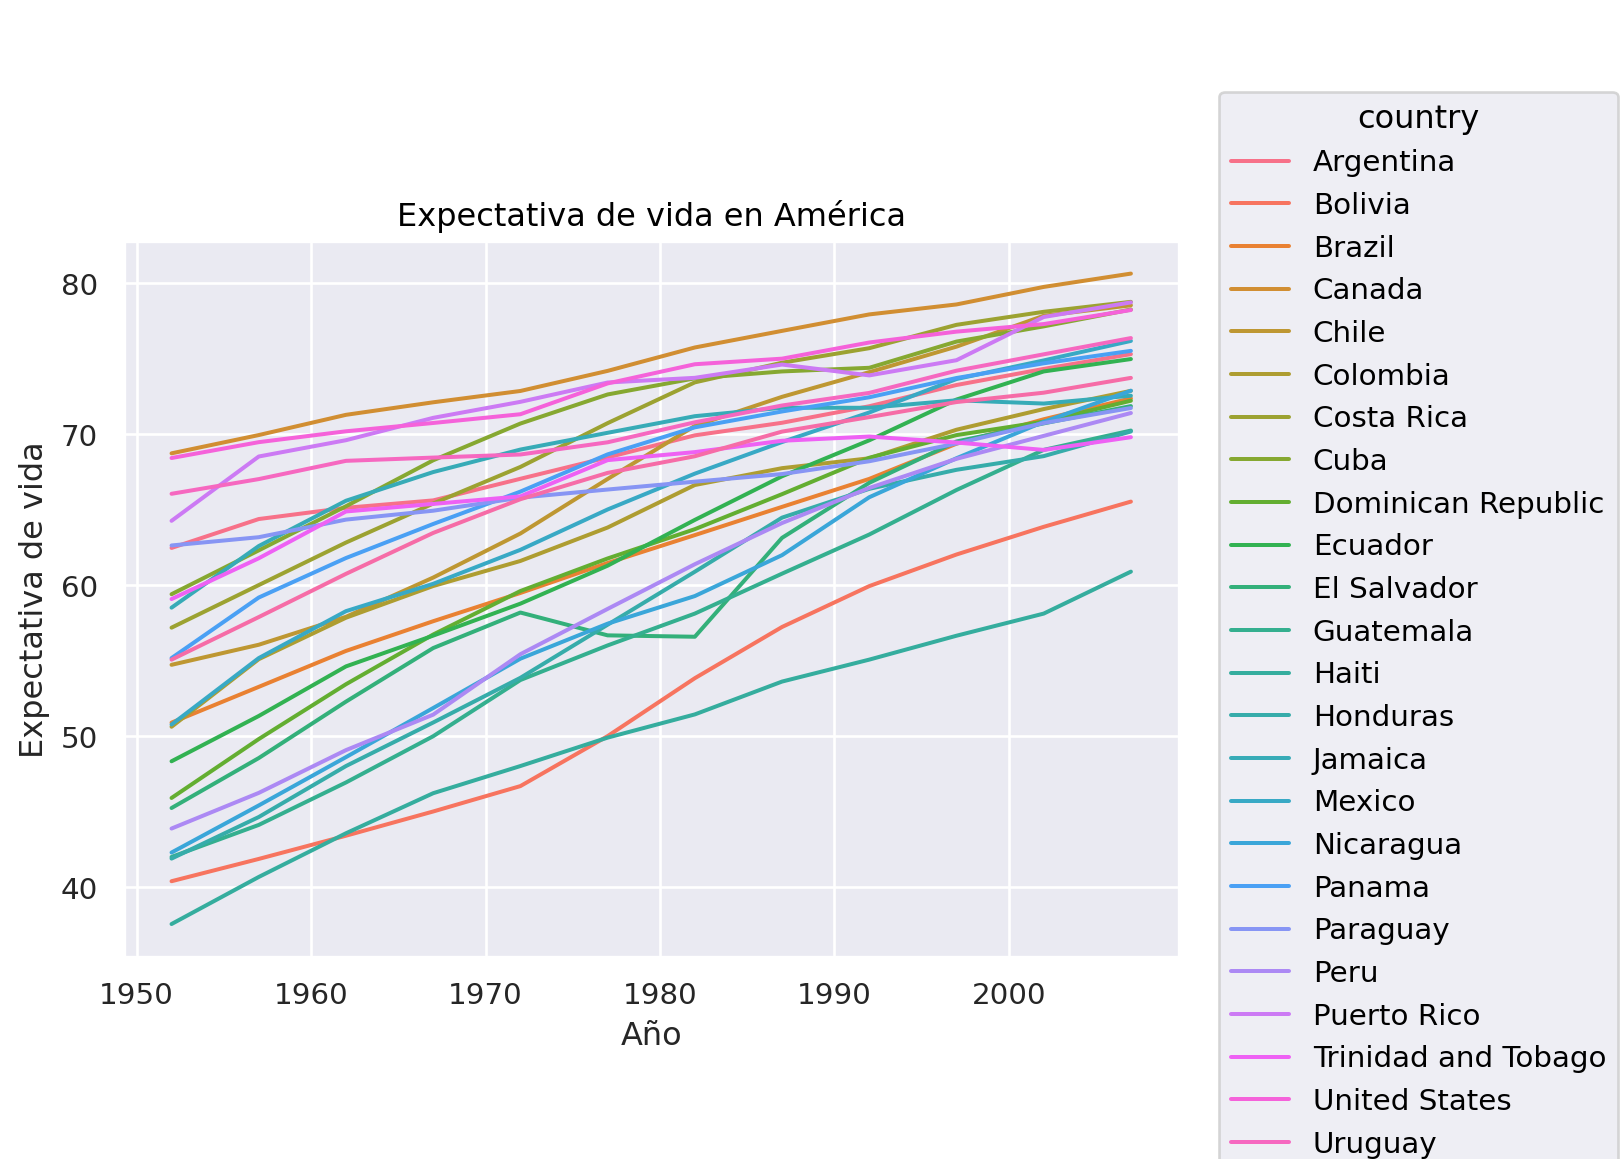

In [18]:
datosAmerica = gapminder[gapminder['continent']== 'Americas']
(    so.Plot(data=datosAmerica, x='year', y='lifeExp', color='country')
    .add(so.Line())
    .label(title='Expectativa de vida en América', x='Año', y='Expectativa de vida')
)

(c) Queremos agregar al gráfico del item anterior una curva de tendencia lineal utilizando el método .add(so.Line(),so.PolyFit(1)) ¿ Cuál de las siguientes dos formas de agrupar los datos es la forma correcta? . Explicar la diferencia

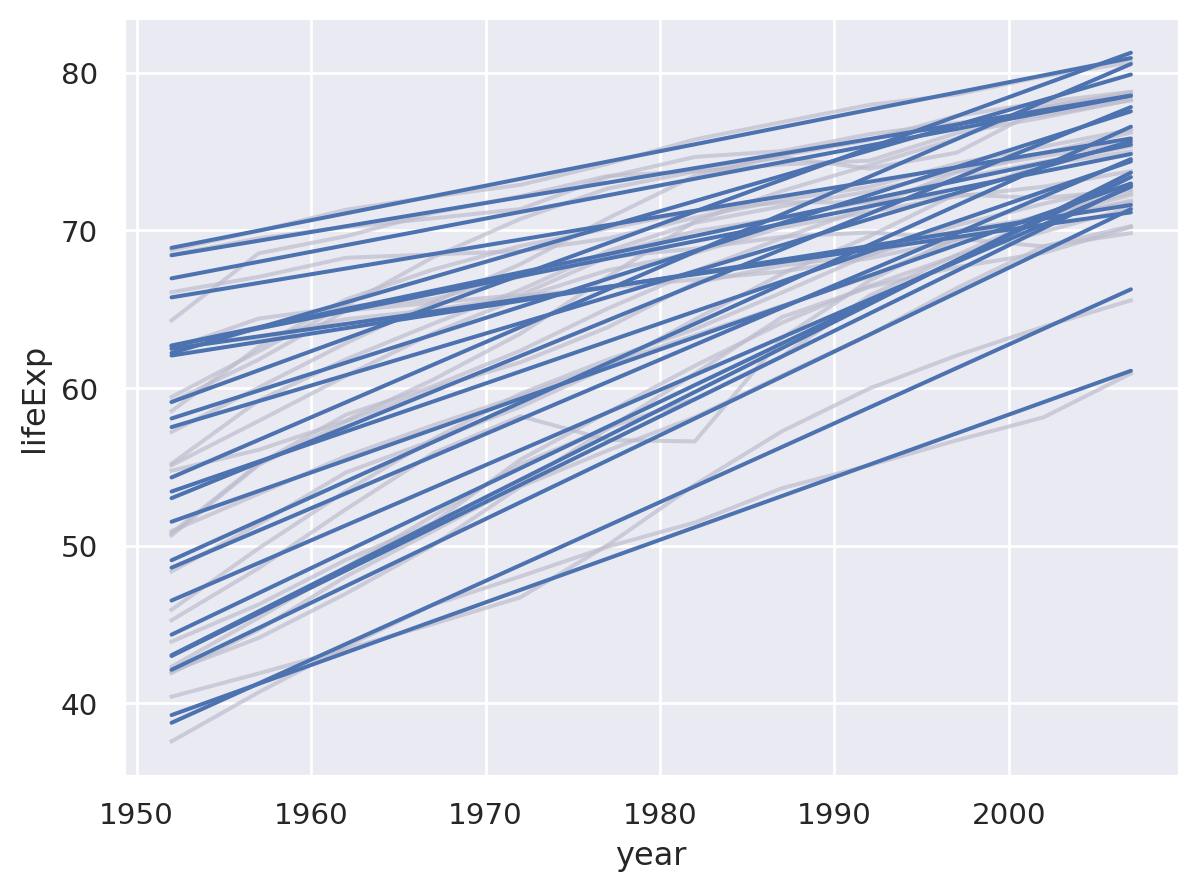

In [ ]:
(
    so.Plot(data = datosAmerica, x = 'year',y ='lifeExp',group = 'country')
    .add(so.Lines(color="#bbca"))
    .add(so.Line(),so.PolyFit(1))
)
# Éste código hace un ajuste de regresión lineal a todos los datos juntos, sin importar el país al que correspondan. Es decir, hace un ajuste de regresión lineal a todos los puntos del gráfico, sin importar a qué país correspondan.

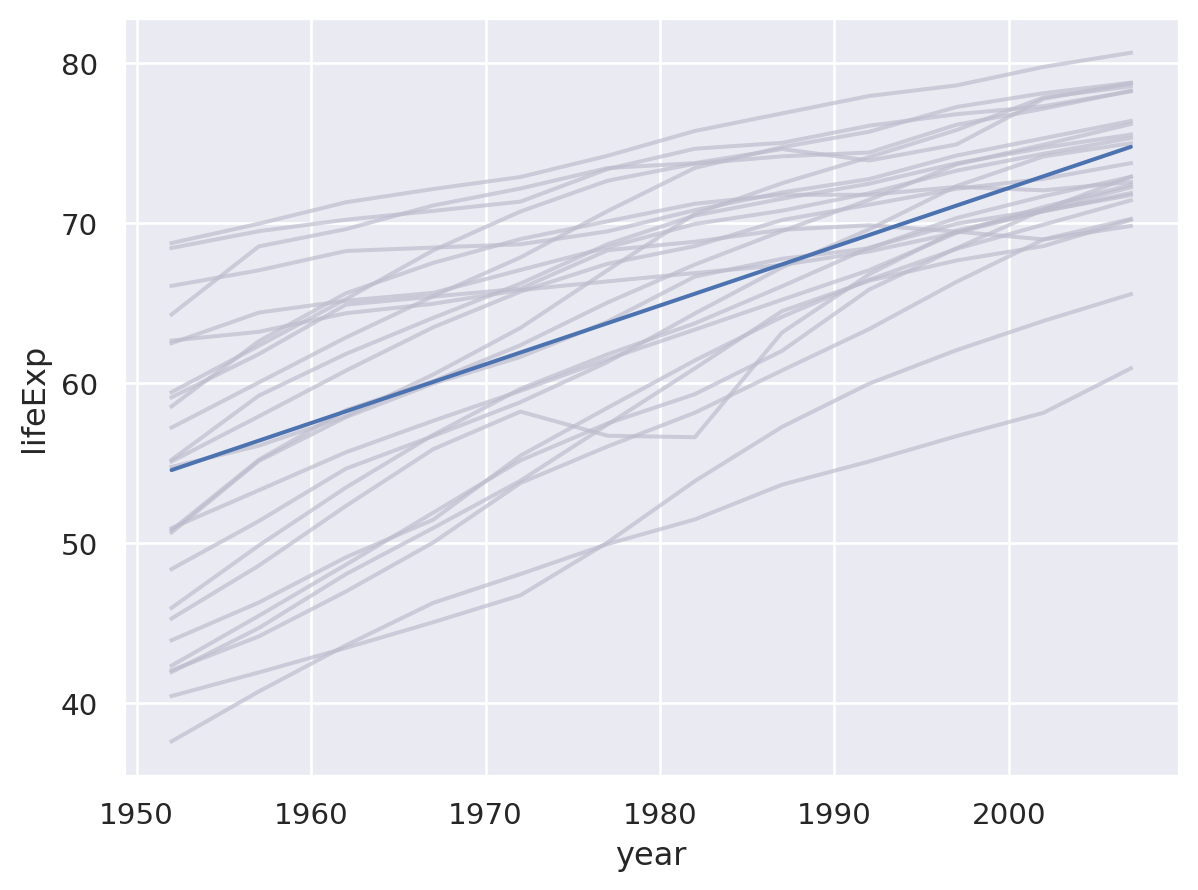

In [ ]:
(
    so.Plot(data = datosAmerica, x = 'year',y ='lifeExp')
    .add(so.Lines(color="#bbca"), group = 'country')
    .add(so.Line(),so.PolyFit(1))
)

# Éste código , a diferencia del anterior, hace un ajuste de regresión lineal a cada país, en vez de a todos los datos juntos.

La correcta es la segunda opción, que muestra como evoluciona le expectativa de vida en los distintos países del dataset con el pasar del tiempo.

La primera opción, hace una regresión lineal por cada país, lo cual termina en un gráfico confuso.

(d) Realizar el siguiente gráfico, con las curvas de expectativa de vida agrupadas por continente. Basándose en el código del ítem (c), completar el siguiente código.

In [28]:
gapContinents =gapminder.groupby('continent')
gapContinents.groups.keys()
gapContinents.get_group('Americas')

,country,year,pop,continent,lifeExp,gdpPercap
48,Argentina,1952,17876956.0,Americas,62.485,5911.315053
49,Argentina,1957,19610538.0,Americas,64.399,6856.856212
50,Argentina,1962,21283783.0,Americas,65.142,7133.166023
51,Argentina,1967,22934225.0,Americas,65.634,8052.953021
52,Argentina,1972,24779799.0,Americas,67.065,9443.038526
...,...,...,...,...,...,...
1639,Venezuela,1987,17910182.0,Americas,70.190,9883.584648
1640,Venezuela,1992,20265563.0,Americas,71.150,10733.926310
1641,Venezuela,1997,22374398.0,Americas,72.146,10165.495180
1642,Venezuela,2002,24287670.0,Americas,72.766,8605.047831


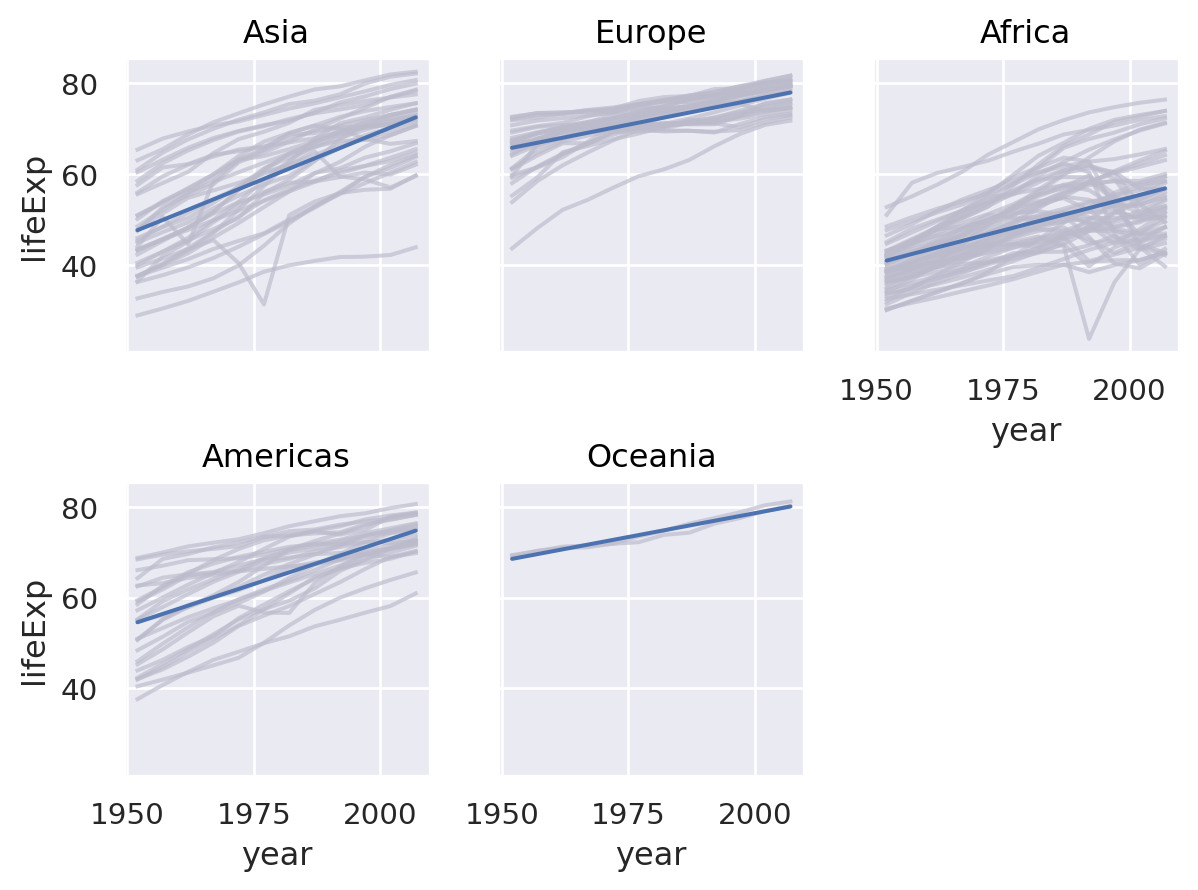

In [38]:
(
    so.Plot(data = gapminder, x = 'year',y ='lifeExp')
    .add(so.Lines(color="#bbca"), group = 'country')
    .add(so.Line(),so.PolyFit(1))
    .facet("continent",wrap=3)
)

facet() crea múltiples gráficos individuales basados en una variable categórica (en éste caso el continente).

El parámetro wrap indica cuántos gráficos vamos a poner en cada fila.